Step 1 - setup and feature extraction

In [13]:
# --- IMPORTS & DEVICE ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.models.resnet import resnet18
from torch.utils.data import DataLoader, Subset
from collections import OrderedDict
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
EMBEDDINGS_PATH = 'cifar10_simclr_embeddings.pt'

Using device: cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [ ]:
# typiclust algorithm
budgets = [10, 20, 30, 40, 50, 60]
initial_laballed_list = []
all_typical_ids = {}


data = torch.load(EMBEDDINGS_PATH)
all_features_normalized = np.array(data['features'])
all_labels = np.array(data['labels'])

for total_budget in budgets:
  print(f"finding typical images for budget: {total_budget}")

  if total_budget <= 50:
    k_means_algorithm = KMeans(n_clusters=total_budget, random_state=42, n_init='auto')
  else: 
    k_means_algorithm = MiniBatchKMeans(n_clusters=total_budget, random_state=42, n_init='auto')


  cluster_assignments = k_means_algorithm.fit_predict(all_features_normalized)

  if len(initial_laballed_list) != 0:
    covered_clusters = set(cluster_assignments[initial_laballed_list])
  else:
    covered_clusters = set()

  all_clusters = set()
  for i in range(total_budget):
    all_clusters.add(i)

  uncovered_clusters = list(all_clusters - covered_clusters)

  # sort the uncovered clusters by highest density
  uncovered_density = []
  for cluster in uncovered_clusters:
    size = np.sum(cluster_assignments == cluster)
    uncovered_density.append((cluster, size))

  uncovered_density.sort(key=lambda x: x[1], reverse=True)

  needed_new = total_budget - len(initial_laballed_list)
  final_clusters = []
  limit = min(needed_new, len(uncovered_density))

  for i in range(limit):
    cluster_id = uncovered_density[i][0]
    final_clusters.append(cluster_id)


  # --------- typiclust --------------
  nearest = NearestNeighbors(algorithm='brute', n_jobs=-1)

  final_typical_images = []

  for i in final_clusters:
    cluster_i = np.where(cluster_assignments == i)[0]
    cluster_features = all_features_normalized[cluster_i]

    cluster_size = min(20, len(cluster_features))

    if cluster_size <= 1:
        best_id = cluster_i[0]
    else:
      nearest.set_params(n_neighbors=cluster_size)
      nearest.fit(cluster_features)
      distance, indicies = nearest.kneighbors(cluster_features)


      average_distances = distance.mean(axis=1)

      typicality_score = 1 / (average_distances + 1e-8)

      best = np.argmax(typicality_score)

      best_id = cluster_i[best]

    final_typical_images.append(int(best_id))

    print(f"Budget {total_budget} | Cluster {i} winner: Image #{best_id}")

  final_list = initial_laballed_list + final_typical_images
  all_typical_ids[total_budget] = list(final_list)

  print("All done!")

C:\Users\arnav\AppData\Local\Temp\ipykernel_10864\1872835750.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(EMBEDDINGS_PATH)
C:\Users\arnav\AppData\Lo

finding typical images for budget: 10
Budget 10 | Cluster 0 winner: Image #9162
Budget 10 | Cluster 7 winner: Image #17387
Budget 10 | Cluster 1 winner: Image #42315
Budget 10 | Cluster 4 winner: Image #9178
Budget 10 | Cluster 6 winner: Image #18668
Budget 10 | Cluster 8 winner: Image #22589
Budget 10 | Cluster 3 winner: Image #12071
Budget 10 | Cluster 9 winner: Image #30798
Budget 10 | Cluster 2 winner: Image #40502
Budget 10 | Cluster 5 winner: Image #18573
All done!
finding typical images for budget: 20
Budget 20 | Cluster 13 winner: Image #18668
Budget 20 | Cluster 9 winner: Image #30798
Budget 20 | Cluster 1 winner: Image #16995
Budget 20 | Cluster 16 winner: Image #9178
Budget 20 | Cluster 18 winner: Image #28657
Budget 20 | Cluster 8 winner: Image #2145
Budget 20 | Cluster 14 winner: Image #37361
Budget 20 | Cluster 10 winner: Image #12943
Budget 20 | Cluster 2 winner: Image #30397
Budget 20 | Cluster 19 winner: Image #23817
Budget 20 | Cluster 7 winner: Image #32109
Budget 20

In [ ]:
# linear classficiation model
# this needs to be for 10, 20, 30, 40, 50, 60 (cumulative)

accuracies = []

# initialise encoder
encoder = resnet18()
encoder.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
encoder.maxpool = nn.Identity()
encoder.fc = nn.Identity()
encoder.to(device)

for budget in budgets:
    print(f"Testing the model with the {budget} typical images...")
    ids_for_this_budget = all_typical_ids[budget]


    X_train_numpy = all_features_normalized[ids_for_this_budget]
    y_train_numpy = all_labels[ids_for_this_budget]

    X_train = torch.tensor(X_train_numpy, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train_numpy, dtype=torch.long).to(device)

    classifier = nn.Linear(512, 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        classifier.parameters(), 
        lr=2.5, 
        momentum=0.9, 
        nesterov=True,
        weight_decay=0
    )

    epochs = 200
    classifier.train()



    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = classifier(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()


    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
    ])

    test_dataset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=test_transform
    )
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=512, shuffle=False)


    clean_weights = torch.load('cifar10_simclr_cleaned.pth', map_location=device)
    missing, unexpected = encoder.load_state_dict(clean_weights, strict=False)
    encoder.eval()
    classifier.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            features = encoder(images)
    
            features = F.normalize(features, p=2, dim=1)
            
        
            outputs = classifier(features)
        
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    final_accuracy = 100 * correct / total

    accuracies.append(final_accuracy)
    print(f"Accuracy for {budget} labels: {final_accuracy:.2f}%")


print(f"\n results recorded: {accuracies}")

Testing the model with the 10 typical images...
Files already downloaded and verified


c:\Users\arnav\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
C:\Users\arnav\AppData\Local\Temp\ipykernel_10864\1370806338.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly 

Accuracy for 10 labels: 50.56%
Testing the model with the 20 typical images...
Files already downloaded and verified
Accuracy for 20 labels: 56.20%
Testing the model with the 30 typical images...
Files already downloaded and verified
Accuracy for 30 labels: 73.25%
Testing the model with the 40 typical images...
Files already downloaded and verified
Accuracy for 40 labels: 74.95%
Testing the model with the 50 typical images...
Files already downloaded and verified
Accuracy for 50 labels: 78.31%
Testing the model with the 60 typical images...
Files already downloaded and verified
Accuracy for 60 labels: 79.72%

 results recorded: [50.56, 56.2, 73.25, 74.95, 78.31, 79.72]


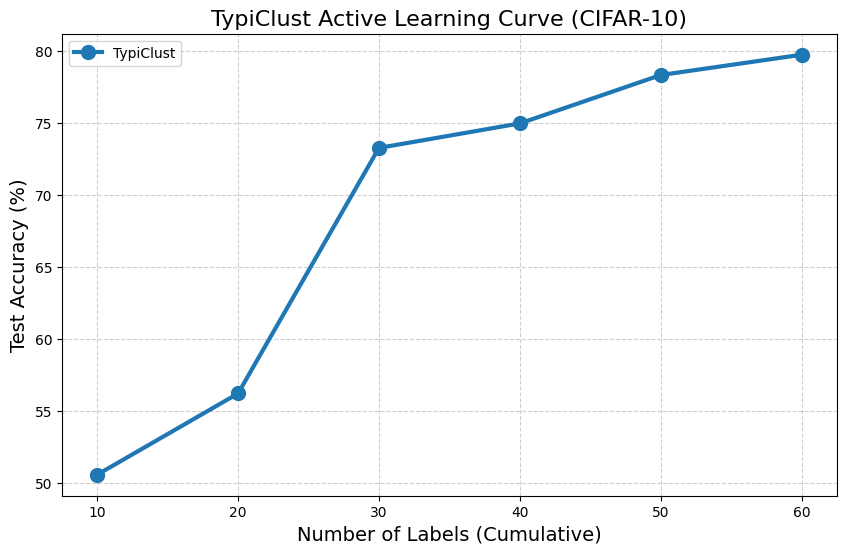

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(budgets, accuracies, marker='o', linewidth=3, markersize=10, label='TypiClust')

plt.title('TypiClust Active Learning Curve (CIFAR-10)', fontsize=16)
plt.xlabel('Number of Labels (Cumulative)', fontsize=14)
plt.ylabel('Test Accuracy (%)', fontsize=14)
plt.xticks(budgets)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

random baseline test

In [59]:
import numpy as np
import random

seeds = [100, 200, 250, 130, 302]
budgets = [10, 20, 30, 40, 50, 60]
all_random_ids = {b: {} for b in budgets}


all_indices = list(range(len(all_labels)))

for total_budget in budgets:
    for seed in seeds:
        random.seed(seed)
        random_sample = random.sample(all_indices, total_budget)
        all_random_ids[total_budget][seed] = random_sample

print(f"Budgets captured: {list(all_random_ids)}")

Budgets captured: [10, 20, 30, 40, 50, 60]


In [60]:
random_accuracies = []

for budget in budgets:
    current_budget_accuracy = []
    for seed in seeds:
        ids = all_random_ids[budget][seed]

        
        X_train = torch.tensor(all_features_normalized[ids], dtype=torch.float32).to(device)
        y_train = torch.tensor(all_labels[ids], dtype=torch.long).to(device)
        
    
        classifier = nn.Linear(512, 10).to(device)
        optimizer = optim.SGD(
            classifier.parameters(), 
            lr=2.5, 
            momentum=0.9, 
            nesterov=True,
            weight_decay=0
        )

    
        classifier.train()
        for epoch in range(200):
            optimizer.zero_grad()
            outputs = classifier(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            optimizer.step()
            

        classifier.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                features = encoder(images)

                features = torch.nn.functional.normalize(features, p=2, dim=1)

                outputs = classifier(features)

                _, pred = torch.max(outputs, 1)

                total += labels.size(0)
                
                correct += (pred == labels).sum().item()
                
        acc = 100 * correct / total
        current_budget_accuracy.append(acc)
        print(f"Budget {budget} | Random Accuracy: {acc:.2f}%")
    
    budget_mean = np.mean(current_budget_accuracy)
    random_accuracies.append(budget_mean)

print(f"Random:     {random_accuracies}")

Budget 10 | Random Accuracy: 24.58%
Budget 10 | Random Accuracy: 35.08%
Budget 10 | Random Accuracy: 33.99%
Budget 10 | Random Accuracy: 37.83%
Budget 10 | Random Accuracy: 31.43%
Budget 20 | Random Accuracy: 53.78%
Budget 20 | Random Accuracy: 43.61%
Budget 20 | Random Accuracy: 51.13%
Budget 20 | Random Accuracy: 43.75%
Budget 20 | Random Accuracy: 53.48%
Budget 30 | Random Accuracy: 64.67%
Budget 30 | Random Accuracy: 58.20%
Budget 30 | Random Accuracy: 63.50%
Budget 30 | Random Accuracy: 48.61%
Budget 30 | Random Accuracy: 61.45%
Budget 40 | Random Accuracy: 68.63%
Budget 40 | Random Accuracy: 62.87%
Budget 40 | Random Accuracy: 66.79%
Budget 40 | Random Accuracy: 55.64%
Budget 40 | Random Accuracy: 64.48%
Budget 50 | Random Accuracy: 71.14%
Budget 50 | Random Accuracy: 67.86%
Budget 50 | Random Accuracy: 71.19%
Budget 50 | Random Accuracy: 62.38%
Budget 50 | Random Accuracy: 65.69%
Budget 60 | Random Accuracy: 73.56%
Budget 60 | Random Accuracy: 71.14%
Budget 60 | Random Accuracy:

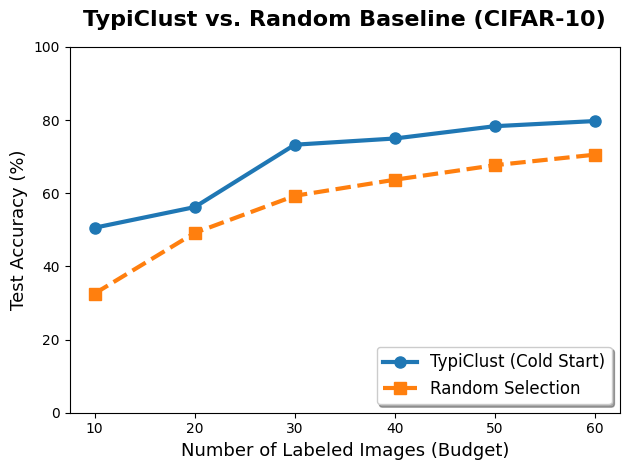

In [61]:
plt.plot(budgets, accuracies, 
         marker='o', markersize=8, linewidth=3, color='#1f77b4', 
         label='TypiClust (Cold Start)')


plt.plot(budgets, random_accuracies, 
         marker='s', markersize=8, linewidth=3, color='#ff7f0e', linestyle='--',
         label='Random Selection')


plt.title('TypiClust vs. Random Baseline (CIFAR-10)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Labeled Images (Budget)', fontsize=13)
plt.ylabel('Test Accuracy (%)', fontsize=13)
plt.xticks(budgets)
plt.ylim(0, 100) # Full scale to show the true context of the performance
plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

Fully Supervised Framework

In [ ]:

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

full_train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, transform=train_transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, transform=test_transform, download=True)

subset_dataset = Subset(full_train_dataset, final_typical_images)
subset_dataset_loader = DataLoader(subset_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

model = resnet18()
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=2.5, momentum=0.9, weight_decay=5e-4)
epochs = 200

model.train()
for epoch in range(epochs):
    for raw_images, labels in subset_dataset_loader:
        raw_images, labels = raw_images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(raw_images) 
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


# testing
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for test_images, test_labels in test_loader:
        test_images, test_labels = test_images.to(device), test_labels.to(device)
        
        outputs = model(test_images) 
        _, predicted = torch.max(outputs.data, 1)
        
        total += test_labels.size(0)
        correct += (predicted == test_labels).sum().item()

final_accuracy = 100 * correct / total
print(f"==========================================")
print(f"FULLY SUPERVISED ACCURACY: {final_accuracy:.2f}%")
print(f"==========================================")


Files already downloaded and verified


c:\Users\arnav\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
FULLY SUPERVISED ACCURACY: 22.22%
